1.3 : Lựa chọn dữ liệu => Chọn TEXT 
Tập DataInput_TEXT :

1. "Trí tuệ nhân tạo đang thay đổi thế giới công nghệ"
2. "Mô hình học máy cần dữ liệu lớn để huấn luyện"
3. "Mạng nơ ron nhân tạo mô phỏng bộ não con người"
4. "Ứng dụng AI giúp tự động hóa nhiều quy trình phức tạp"
5. "Công thức nấu phở bò truyền thống cần nhiều gia vị"
6. "Món ăn Việt Nam luôn đậm đà và phong phú"
7. "Cách làm bánh mì tại nhà rất đơn giản và ngon"
8. "Hướng dẫn nấu lẩu thái hải sản chua cay hấp dẫn"




CHUYỂN DỮ LIỆU THÀNH MA TRẬN 

In [31]:
import numpy as np 
input_TEXT= [
    "Trí tuệ nhân tạo đang thay đổi thế giới công nghệ",
    "Mô hình học máy cần dữ liệu lớn để huấn luyện",
    "Mạng nơ ron nhân tạo mô phỏng bộ não con người",
    "Ứng dụng AI giúp tự động hóa nhiều quy trình phức tạp",
    "Công thức nấu phở bò truyền thống cần nhiều gia vị",
    "Món ăn Việt Nam luôn đậm đà và phong phú",
    "Cách làm bánh mì tại nhà rất đơn giản và ngon",
    "Hướng dẫn nấu lẩu thái hải sản chua cay hấp dẫn"
    ]
vocab = sorted({ word for sentence in input_TEXT for word in sentence.lower().split()})
# print(vocab)
# print(len(vocab))
def to_vector (sentence):
    vector = np.zeros(len(vocab))  
    for word in sentence.lower().split():
        if word in vocab:
            vector[vocab.index(word)] += 1 # giá trị của mỗi ô trogn vector là tần suất xuất hiện của từ 
    return vector 

X = np.array([to_vector(sentence) for sentence in input_TEXT])

print(X.shape)

# for x in X : print(x)


(8, 79)


BÀI 1 : Biểu diễn dữ liệu thành ma trận & độ tương đồng 


1. Biến dữ liệu thành ma trận 
 Ma trận X kích thước 8 x 79 với 8 câu trong tập input_TEXT và 79 là len(vocab) với tập Set vocab chứa các phần tử là các từ duy nhất được sắp xếp theo thứ tự từ A->Z , mà mỗi từ (phần tử trong vocab) sẽ đại diện cho mỗi cột của X 

2. Phép toán cơ bản 

2.1. Tìm vector trung bình theo cột 

In [32]:
# vector_tb_col =np.array([])  # vector trung trình theo cột 
# col= X.shape[1]
# row= X.shape[0]

# for i in range(col):
#     sum_col =0
#     for j in range(row):
#         sum_col+= X[j][i]
#     vector_tb_col=np.append(vector_tb_col , sum_col/row) #numpy :kích thước cố định , phải cập nhật mảng bằng cách sao chép lại mảnh củ,tốn bộ nhớ ; khác với list có kích thước động , tự dộng update 

# print(vector_tb_col.shape)
# print(vector_tb_col)

# Trong numpy
vec_tb_col = X.mean(axis=0)
print(vec_tb_col)


[0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.25  0.25  0.25  0.125
 0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125
 0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.25  0.125 0.125
 0.125 0.125 0.125 0.25  0.125 0.25  0.125 0.125 0.25  0.125 0.125 0.125
 0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125
 0.125 0.125 0.125 0.125 0.25  0.125 0.125 0.125 0.25  0.125 0.125 0.125
 0.125 0.125 0.125 0.125 0.125 0.125 0.125]


2.2. Trừ trung bình (broadcasting )

In [33]:
# Ma trận X sau khi trừ vec_tb_col
X_trungbinh = X - vec_tb_col 
print(X_trungbinh)


[[-0.125 -0.125 -0.125 -0.125 -0.125 -0.125 -0.125 -0.125  0.75  -0.25
  -0.25  -0.125 -0.125 -0.125 -0.125 -0.125  0.875 -0.125 -0.125 -0.125
  -0.125 -0.125 -0.125 -0.125 -0.125 -0.125 -0.125 -0.125 -0.125 -0.125
  -0.125 -0.125 -0.125 -0.25  -0.125 -0.125  0.875 -0.125 -0.125 -0.25
  -0.125  0.75  -0.125 -0.125 -0.25  -0.125 -0.125 -0.125 -0.125 -0.125
  -0.125 -0.125 -0.125 -0.125  0.875 -0.125  0.875 -0.125 -0.125 -0.125
  -0.125  0.875  0.875 -0.125  0.75  -0.125 -0.125 -0.125 -0.25  -0.125
  -0.125  0.875 -0.125 -0.125 -0.125 -0.125  0.875 -0.125 -0.125]
 [-0.125 -0.125 -0.125 -0.125 -0.125 -0.125 -0.125 -0.125 -0.25   0.75
  -0.25  -0.125  0.875 -0.125 -0.125 -0.125 -0.125  0.875  0.875 -0.125
  -0.125 -0.125 -0.125  0.875  0.875  0.875 -0.125 -0.125 -0.125  0.875
   0.875 -0.125 -0.125  0.75  -0.125 -0.125 -0.125 -0.125 -0.125 -0.25
  -0.125 -0.25  -0.125 -0.125 -0.25  -0.125 -0.125 -0.125 -0.125 -0.125
  -0.125 -0.125 -0.125 -0.125 -0.125 -0.125 -0.125 -0.125 -0.125 -0.125
  

2.3. In shape của X trước và sau khi trừ vec_tb_col

In [34]:
print(X.shape)
print(X_trungbinh.shape)

(8, 79)
(8, 79)


3. Cosine similarity

In [36]:
def cosine_similarity(X, Y=None):
    if Y is None: 
        Y = X  # tức cosine_sim=1 
    # chuẩn hóa vector(L2 Norm)
    X_n = X / np.linalg.norm(X, axis=1, keepdims=True)
    Y_n = Y / np.linalg.norm(Y, axis=1, keepdims=True)
    
    #cosine_similarity= X_n @ (Y_n.T)
    return np.dot(X_n, Y_n.T)

# Ma trận độ tương đồng giữa các câu với nhau
Sim_matrix = cosine_similarity(X)

# print(Sim_matrix)

def search(query, top_k=3):
    # Transform câu truy vấn query về dạng vector 
    query_vector = to_vector(query).reshape(1, -1)
    
    # Tính cosine similarity giữa query và tất cả các câu trong X
    sim_scores = cosine_similarity(X, query_vector) 
    sim_scores=sim_scores.reshape(-1) # đưa về ma trận 1D
    # print(sim_scores)
 
    # lấy top_k(k câu có độ tương dồng nhất với query)
    
    idx_arr = np.argsort(sim_scores)[::-1] # Lấy chỉ số sắp xếp giảm dần tương ứng với chỉ số của câu trog input_TEXT
    top_k_arr= idx_arr[:top_k]
    # in ra Top_k 
    for i in range(top_k):
        print(f"{i+1}. {input_TEXT[top_k_arr[i]]} ")
    #in câu khác biệt nhất
    print(f' Câu khác biệt nhất : {input_TEXT[idx_arr[-1]]}')     

# Chạy thử nghiệm hàm search
search("Tôi muốn học máy tính và trí tuệ nhân tạo", top_k=3)

1. Trí tuệ nhân tạo đang thay đổi thế giới công nghệ 
2. Mạng nơ ron nhân tạo mô phỏng bộ não con người 
3. Mô hình học máy cần dữ liệu lớn để huấn luyện 
 Câu khác biệt nhất : Ứng dụng AI giúp tự động hóa nhiều quy trình phức tạp


Bài 2 - Biến đổi tuyến tính & SVD

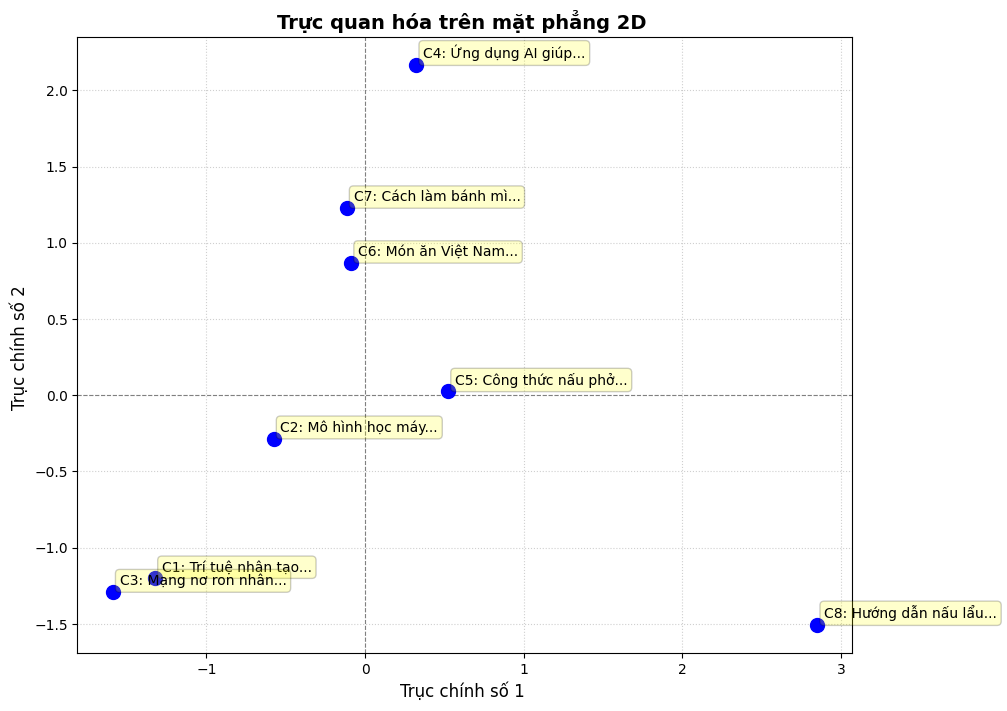

In [ ]:
import matplotlib.pyplot as plt

# X_trungbinh từ mục 2.2. Trừ trung bình (broadcasting )
X_c= X_trungbinh
# Giảm chiều bằng SVD
U, S, Vt = np.linalg.svd(X_c, full_matrices=False)

#tọa độ 2 chiều (2D) tốt nhất cho mỗi câu dữ liệu
coords = U[:, :2] * S[:2]

#vẽ đồ thị Scatter plot không gian dữ liệu
plt.figure(figsize=(10, 8))
plt.scatter(coords[:, 0], coords[:, 1], color='blue', s=100, zorder=3)

# Gắn nhãn tiêu đề rút gọn cho từng câu 
for i, text in enumerate(input_TEXT):
    short_text = f"C{i+1}: " + " ".join(text.split()[:4]) + "..."
    plt.annotate(short_text, (coords[i, 0], coords[i, 1]), textcoords="offset points", xytext=(5,5), ha='left', fontsize=10,bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.2))

plt.title("Trực quan hóa trên mặt phẳng 2D ", fontsize=14, fontweight='bold')
plt.xlabel("Trục chính số 1 ", fontsize=12)
plt.ylabel("Trục chính số 2 ", fontsize=12)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Nhận xét:
Sự phân cụm theo chủ đề rõ rệt:
Nhóm Công nghệ / AI (C1, C2, C3): Nằm hoàn toàn về phía bên trái của đồ thị (giá trị âm trên Trục chính 1). Đặc biệt, C1 ("Trí tuệ nhân tạo...") và C3 ("Mạng nơ ron nhân tạo...") nằm gần sát nhau vì chúng chia sẻ chung các từ khóa cốt lõi và ngữ nghĩa tương đồng cao.
C4 mặc dù mang ý nghĩa "Công nghệ/AI", nhưng trong câu: "Ứng dụng AI giúp tự động hóa nhiều quy trình phức tạp" , ngoài từ viết tắt "AI" ra, tất cả các từ còn lại như "ứng dụng", "giúp", "tự", "động", "hóa", "nhiều", "quy", "trình", "phức", "tạp" đều hoàn toàn mới và không hề xuất hiện trong C1, C2, C3

Nhóm Ẩm thực / Nấu ăn (C5, C6, C7, C8): Nằm tách biệt hẳn về phía bên phải của đồ thị (giá trị dương trên Trục chính 1).

* Trục chính số 1 (Component 1 - Trục hoành): Đóng vai trò là trục phân loại ngữ nghĩa chính. Nó giúp phân định ranh giới giữa hai thế giới "Công nghệ" (bên trái) và "Ẩm thực" (bên phải).

* Trục chính số 2 (Component 2 - Trục tung): Thể hiện sự biến thiên ngữ nghĩa nội bộ trong cùng một chủ đề (ví dụ: phân tách giữa các món ăn khô/bánh như C7 với món nước/lẩu như C8)